In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from astropy.table import Table
from astropy import units as u
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia
import warnings
warnings.filterwarnings('ignore')

# Set Gaia data release to DR3
Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source"
Gaia.ROW_LIMIT = -1

print("Gaia DR3 pipeline initialised")
print(f"Querying table: {Gaia.MAIN_GAIA_TABLE}")

Maintenance with possible short-time disconnections: 29 June 2026 18:00–20:00 CEST
Gaia DR3 pipeline initialised
Querying table: gaiadr3.gaia_source


In [10]:
# Hyades cluster centre coordinates
hyades_ra = 66.5
hyades_dec = 15.87
search_radius = 10.0

# Fixed query - parallax_over_noise computed inline
query = f"""
SELECT
    source_id,
    ra,
    dec,
    parallax,
    parallax_error,
    pmra,
    pmdec,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,
    bp_rp,
    (parallax / parallax_error) AS parallax_snr
FROM gaiadr3.gaia_source
WHERE CONTAINS(
    POINT('ICRS', ra, dec),
    CIRCLE('ICRS', {hyades_ra}, {hyades_dec}, {search_radius})
) = 1
AND parallax BETWEEN 15 AND 30
AND parallax_error > 0
AND (parallax / parallax_error) > 10
AND phot_g_mean_mag IS NOT NULL
AND bp_rp IS NOT NULL
"""

print("Query updated successfully")
print(f"Search centre: RA={hyades_ra}°, Dec={hyades_dec}°")
print(f"Search radius: {search_radius} degrees")
print(f"Parallax range: 15-30 mas (33-67 parsecs)")

Query updated successfully
Search centre: RA=66.5°, Dec=15.87°
Search radius: 10.0 degrees
Parallax range: 15-30 mas (33-67 parsecs)


In [11]:
print("Submitting query to ESA Gaia DR3 archive...")
print("This may take 30-60 seconds depending on server load...")

job = Gaia.launch_job_async(query)
results = job.get_results()

print(f"\nQuery completed successfully")
print(f"Total stars returned: {len(results)}")
print(f"Columns available: {results.colnames}")
print(f"\nFirst 5 rows:")
print(results[:5])

Submitting query to ESA Gaia DR3 archive...
This may take 30-60 seconds depending on server load...
INFO: Query finished. [astroquery.utils.tap.core]

Query completed successfully
Total stars returned: 1133
Columns available: ['source_id', 'ra', 'dec', 'parallax', 'parallax_error', 'pmra', 'pmdec', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'bp_rp', 'parallax_snr']

First 5 rows:
     source_id              ra         ...   bp_rp      parallax_snr   
                           deg         ...    mag                      
------------------- ------------------ ... --------- ------------------
3306410861213397504  70.04287736925004 ... 2.3444357  676.0612143970001
3303772170746554240 60.859979842902625 ... 2.6431189    543.00443175457
3298668650087227008 61.554453897213214 ... 0.6236205 44.494173894348336
3302997083768142464  59.82920498195217 ... 2.7403412  584.4879370131969
  49013552603400320  65.03202416992305 ... 2.6911917  522.6380969867328


In [12]:
# Basic inspection
print(f"Dataset shape: {len(results)} stars, {len(results.colnames)} columns")
print(f"\nColumn names: {results.colnames}")
print(f"\nData summary:")

# Check for any remaining nulls
for col in results.colnames:
    null_count = np.sum(results[col].mask) if hasattr(results[col], 'mask') else 0
    print(f"  {col}: min={np.nanmin(results[col]):.3f}, "
          f"max={np.nanmax(results[col]):.3f}, "
          f"nulls={null_count}")

Dataset shape: 1133 stars, 12 columns

Column names: ['source_id', 'ra', 'dec', 'parallax', 'parallax_error', 'pmra', 'pmdec', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'bp_rp', 'parallax_snr']

Data summary:
  source_id: min=36629890579758592.000, max=3413660833158428160.000, nulls=0
  ra: min=56.479, max=76.789, nulls=0
  dec: min=6.103, max=25.749, nulls=0
  parallax: min=15.002, max=29.998, nulls=0
  parallax_error: min=0.012, max=2.672, nulls=0
  pmra: min=-236.028, max=860.716, nulls=0
  pmdec: min=-1105.331, max=225.696, nulls=0
  phot_g_mean_mag: min=3.280, max=20.917, nulls=0
  phot_bp_mean_mag: min=3.575, max=21.761, nulls=0
  phot_rp_mean_mag: min=2.662, max=19.424, nulls=0
  bp_rp: min=-0.391, max=4.728, nulls=0
  parallax_snr: min=10.511, max=1857.709, nulls=0


In [13]:
# Convert to numpy arrays for filtering
ra = np.array(results['ra'])
dec = np.array(results['dec'])
parallax = np.array(results['parallax'])
parallax_error = np.array(results['parallax_error'])
pmra = np.array(results['pmra'])
pmdec = np.array(results['pmdec'])
g_mag = np.array(results['phot_g_mean_mag'])
bp_rp = np.array(results['bp_rp'])
parallax_snr = np.array(results['parallax_snr'])

# Hyades known proper motion centre
hyades_pmra = 105.0   # mas/yr
hyades_pmdec = -28.0  # mas/yr
pm_tolerance = 20.0   # mas/yr — generous to include stream members

# Calculate proper motion distance from cluster mean
pm_distance = np.sqrt(
    (pmra - hyades_pmra)**2 + 
    (pmdec - hyades_pmdec)**2
)

# Apply proper motion filter
pm_mask = pm_distance < pm_tolerance

# Apply tighter parallax filter around Hyades distance
# Hyades is at 46.7 pc = parallax of 21.4 mas
parallax_mask = (parallax > 18) & (parallax < 26)

# Combine both filters
member_mask = pm_mask & parallax_mask

# Apply masks to all arrays
ra_mem = ra[member_mask]
dec_mem = dec[member_mask]
parallax_mem = parallax[member_mask]
pmra_mem = pmra[member_mask]
pmdec_mem = pmdec[member_mask]
g_mag_mem = g_mag[member_mask]
bp_rp_mem = bp_rp[member_mask]

print(f"Stars before proper motion filter : {len(pmra)}")
print(f"Stars after proper motion filter  : {np.sum(pm_mask)}")
print(f"Stars after parallax refinement   : {np.sum(member_mask)}")
print(f"\nProper motion of selected members:")
print(f"  pmra  : {np.mean(pmra_mem):.2f} ± {np.std(pmra_mem):.2f} mas/yr")
print(f"  pmdec : {np.mean(pmdec_mem):.2f} ± {np.std(pmdec_mem):.2f} mas/yr")
print(f"\nParallax of selected members:")
print(f"  Mean  : {np.mean(parallax_mem):.3f} mas")
print(f"  Std   : {np.std(parallax_mem):.3f} mas")
print(f"  Distance: {1000/np.mean(parallax_mem):.1f} parsecs")

Stars before proper motion filter : 1133
Stars after proper motion filter  : 319
Stars after parallax refinement   : 301

Proper motion of selected members:
  pmra  : 104.52 ± 9.03 mas/yr
  pmdec : -27.11 ± 9.04 mas/yr

Parallax of selected members:
  Mean  : 21.263 mas
  Std   : 1.329 mas
  Distance: 47.0 parsecs


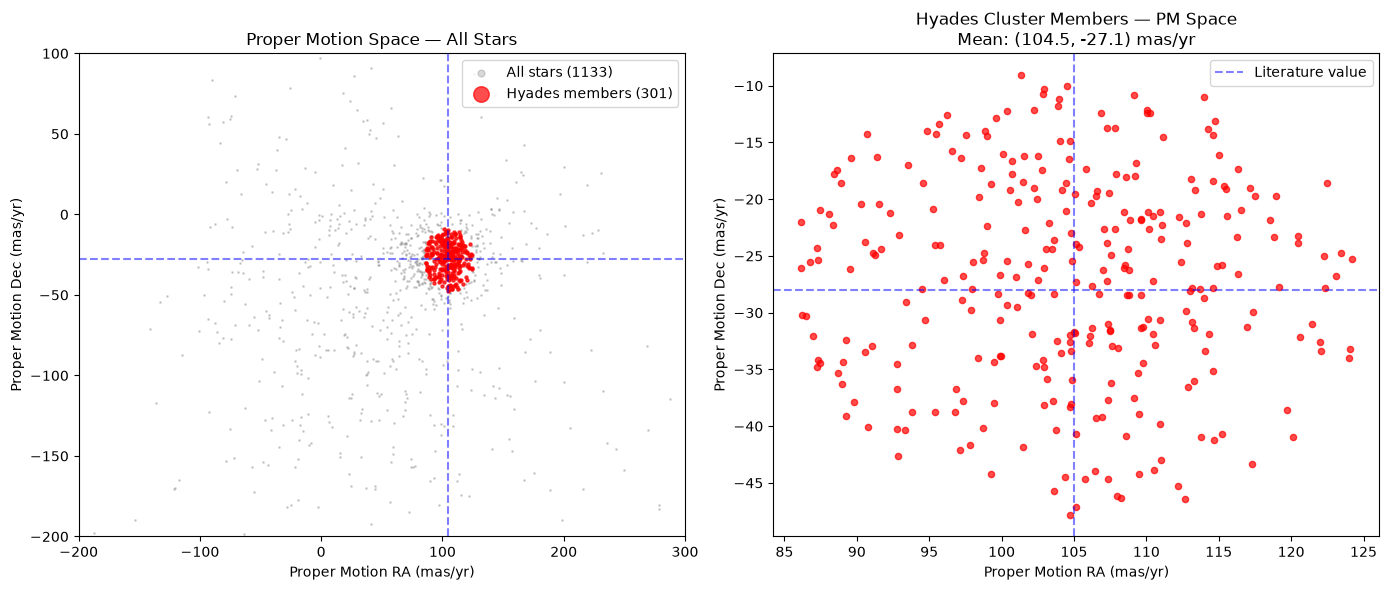

Total confirmed members: 301


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel — all stars from initial query
axes[0].scatter(
    pmra, pmdec,
    s=1, alpha=0.3, color='gray', label='All stars (1133)'
)
axes[0].scatter(
    pmra_mem, pmdec_mem,
    s=5, alpha=0.7, color='red', label=f'Hyades members ({len(pmra_mem)})'
)
axes[0].set_xlim(-200, 300)
axes[0].set_ylim(-200, 100)
axes[0].set_xlabel('Proper Motion RA (mas/yr)')
axes[0].set_ylabel('Proper Motion Dec (mas/yr)')
axes[0].set_title('Proper Motion Space — All Stars')
axes[0].legend(markerscale=5)
axes[0].axvline(x=hyades_pmra, color='blue', linestyle='--', alpha=0.5)
axes[0].axhline(y=hyades_pmdec, color='blue', linestyle='--', alpha=0.5)

# Right panel — zoom into cluster proper motion
axes[1].scatter(
    pmra_mem, pmdec_mem,
    s=20, alpha=0.7, color='red'
)
axes[1].set_xlabel('Proper Motion RA (mas/yr)')
axes[1].set_ylabel('Proper Motion Dec (mas/yr)')
axes[1].set_title(f'Hyades Cluster Members — PM Space\n'
                  f'Mean: ({np.mean(pmra_mem):.1f}, {np.mean(pmdec_mem):.1f}) mas/yr')
axes[1].axvline(x=hyades_pmra, color='blue', 
                linestyle='--', alpha=0.5, label='Literature value')
axes[1].axhline(y=hyades_pmdec, color='blue', linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.savefig('hyades_proper_motion.png', dpi=150)
plt.show()

print(f"Total confirmed members: {len(pmra_mem)}")

In [15]:
# Convert parallax to distance in parsecs for each star
distance_pc = 1000.0 / parallax_mem

# Calculate distance modulus for each star
# This accounts for the fact that each star is at a slightly
# different distance within the cluster
distance_modulus = 5 * np.log10(distance_pc) - 5

# Calculate absolute G magnitude
abs_g_mag = g_mag_mem - distance_modulus

print(f"Distance range of members:")
print(f"  Nearest member : {np.min(distance_pc):.1f} pc")
print(f"  Farthest member: {np.max(distance_pc):.1f} pc")
print(f"  Mean distance  : {np.mean(distance_pc):.1f} pc")
print(f"\nAbsolute magnitude range:")
print(f"  Brightest: M_G = {np.min(abs_g_mag):.2f}")
print(f"  Faintest : M_G = {np.max(abs_g_mag):.2f}")
print(f"\nColour range (BP-RP):")
print(f"  Bluest : {np.min(bp_rp_mem):.3f}")
print(f"  Reddest: {np.max(bp_rp_mem):.3f}")

Distance range of members:
  Nearest member : 39.0 pc
  Farthest member: 55.5 pc
  Mean distance  : 47.2 pc

Absolute magnitude range:
  Brightest: M_G = 0.03
  Faintest : M_G = 17.13

Colour range (BP-RP):
  Bluest : -0.339
  Reddest: 4.314


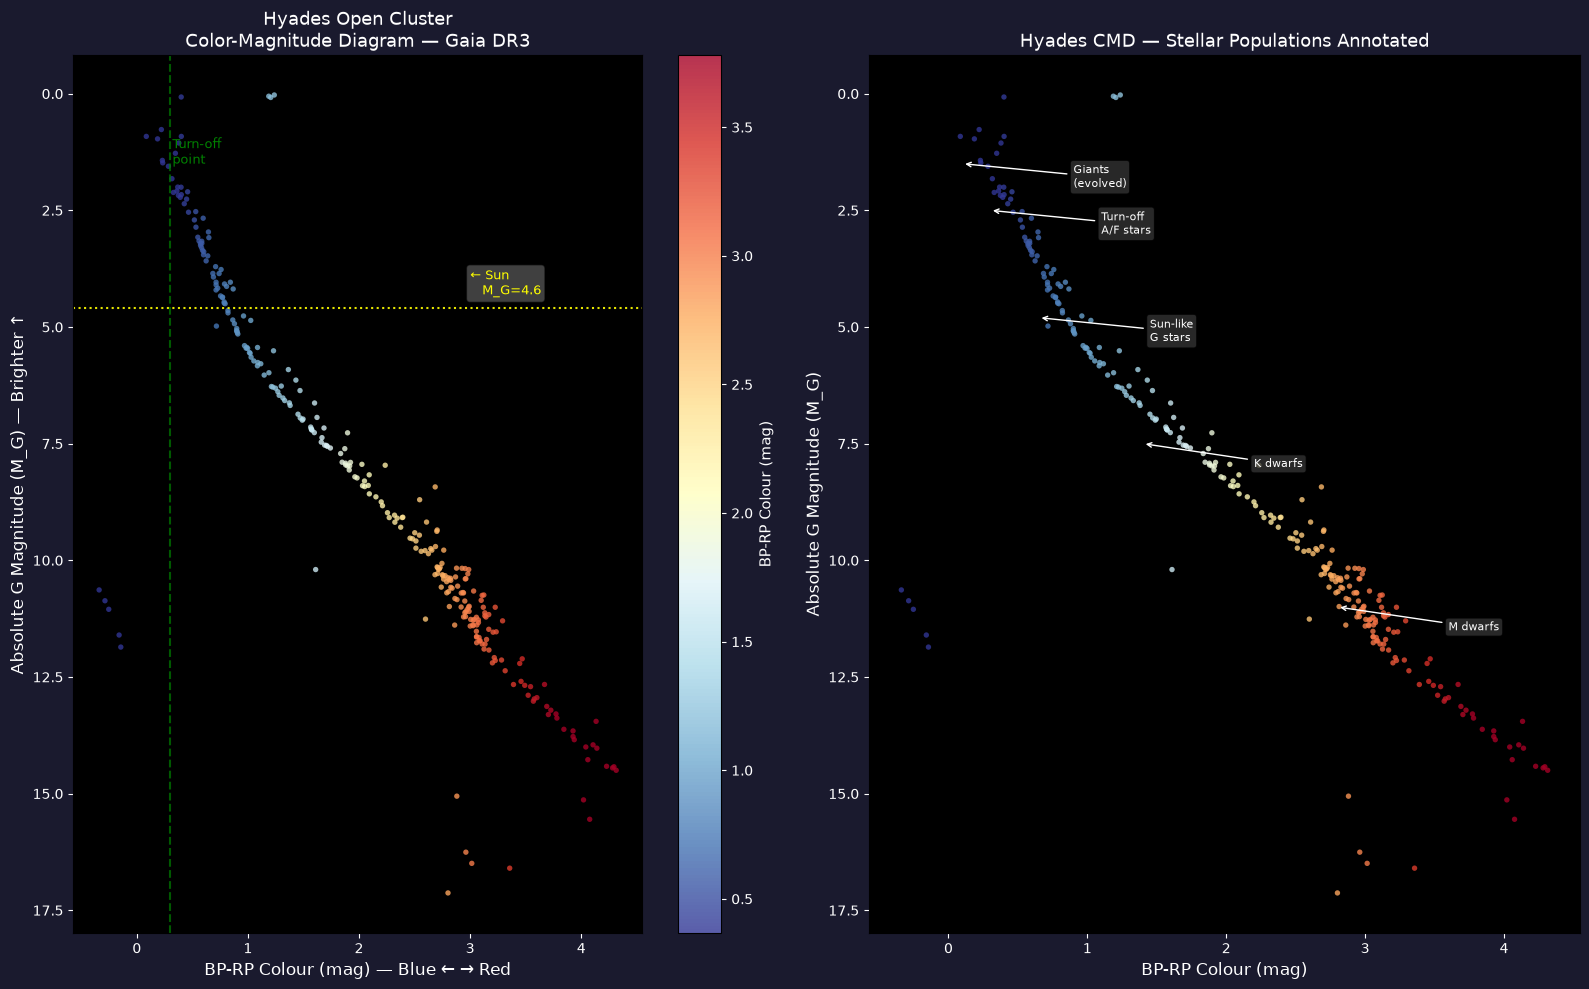

CMD saved to hyades_cmd.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# ── Left panel: CMD coloured by BP-RP ──
norm = mcolors.Normalize(
    vmin=np.percentile(bp_rp_mem, 5),
    vmax=np.percentile(bp_rp_mem, 95)
)
cmap = plt.cm.RdYlBu_r

scatter = axes[0].scatter(
    bp_rp_mem,
    abs_g_mag,
    c=bp_rp_mem,
    cmap=cmap,
    norm=norm,
    s=15,
    alpha=0.8,
    edgecolors='none'
)

# Invert y-axis — brighter stars at top
axes[0].invert_yaxis()

# Colourbar
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('BP-RP Colour (mag)', fontsize=11)

# Annotate stellar features
axes[0].axvline(x=0.3, color='green', linestyle='--',
                alpha=0.7, linewidth=1.5)
axes[0].text(0.32, 1.5, 'Turn-off\npoint',
             color='green', fontsize=9)

axes[0].axhline(y=4.6, color='yellow', linestyle=':',
                alpha=0.9, linewidth=1.5)
axes[0].text(3.0, 4.3, '← Sun\n   M_G=4.6',
             color='yellow', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='gray', alpha=0.5))

axes[0].set_xlabel('BP-RP Colour (mag) — Blue ← → Red', fontsize=12)
axes[0].set_ylabel('Absolute G Magnitude (M_G) — Brighter ↑', fontsize=12)
axes[0].set_title('Hyades Open Cluster\nColor-Magnitude Diagram — Gaia DR3',
                  fontsize=13)
axes[0].set_facecolor('black')
fig.patch.set_facecolor('#1a1a2e')
axes[0].tick_params(colors='white')
axes[0].xaxis.label.set_color('white')
axes[0].yaxis.label.set_color('white')
axes[0].title.set_color('white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
cbar.ax.set_ylabel('BP-RP Colour (mag)', color='white')

# ── Right panel: CMD with stellar type annotations ──
axes[1].scatter(
    bp_rp_mem,
    abs_g_mag,
    c=bp_rp_mem,
    cmap=cmap,
    norm=norm,
    s=15,
    alpha=0.8,
    edgecolors='none'
)
axes[1].invert_yaxis()
axes[1].set_facecolor('black')

# Annotate stellar populations
annotations = [
    (0.1,  1.5,  'Giants\n(evolved)'),
    (0.3,  2.5,  'Turn-off\nA/F stars'),
    (0.65, 4.8,  'Sun-like\nG stars'),
    (1.4,  7.5,  'K dwarfs'),
    (2.8,  11.0, 'M dwarfs'),
]

for x, y, label in annotations:
    axes[1].annotate(
        label,
        xy=(x, y),
        fontsize=8,
        color='white',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='#333333',
                  alpha=0.8),
        arrowprops=dict(arrowstyle='->', color='white', lw=1),
        xytext=(x + 0.8, y + 0.5)
    )

axes[1].set_xlabel('BP-RP Colour (mag)', fontsize=12)
axes[1].set_ylabel('Absolute G Magnitude (M_G)', fontsize=12)
axes[1].set_title('Hyades CMD — Stellar Populations Annotated',
                  fontsize=13)
axes[1].tick_params(colors='white')
axes[1].xaxis.label.set_color('white')
axes[1].yaxis.label.set_color('white')
axes[1].title.set_color('white')

plt.tight_layout()
plt.savefig('hyades_cmd.png', dpi=150, facecolor='#1a1a2e')
plt.show()

print("CMD saved to hyades_cmd.png")

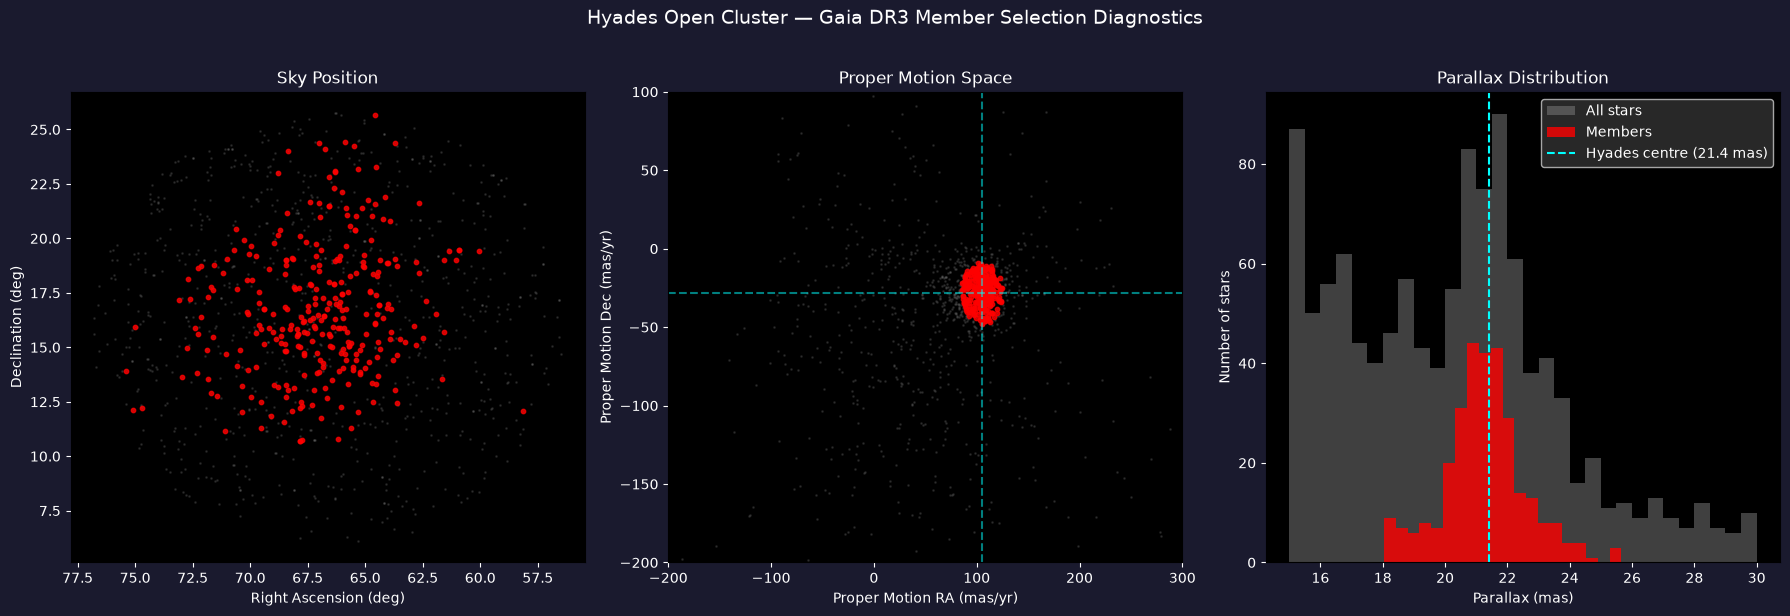

Diagnostic plot saved to hyades_diagnostics.png


In [17]:
# Save a combined summary figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#1a1a2e')

# Panel 1 — Sky positions of members
axes[0].scatter(ra, dec, s=1, alpha=0.2, color='gray')
axes[0].scatter(ra_mem, dec_mem, s=10, alpha=0.8, color='red')
axes[0].set_xlabel('Right Ascension (deg)', color='white')
axes[0].set_ylabel('Declination (deg)', color='white')
axes[0].set_title('Sky Position', color='white')
axes[0].set_facecolor('black')
axes[0].tick_params(colors='white')
axes[0].invert_xaxis()

# Panel 2 — Proper motion space
axes[1].scatter(pmra, pmdec, s=1, alpha=0.2, color='gray')
axes[1].scatter(pmra_mem, pmdec_mem, s=10, alpha=0.8, color='red')
axes[1].set_xlim(-200, 300)
axes[1].set_ylim(-200, 100)
axes[1].set_xlabel('Proper Motion RA (mas/yr)', color='white')
axes[1].set_ylabel('Proper Motion Dec (mas/yr)', color='white')
axes[1].set_title('Proper Motion Space', color='white')
axes[1].set_facecolor('black')
axes[1].tick_params(colors='white')
axes[1].axvline(x=105, color='cyan', linestyle='--', alpha=0.5)
axes[1].axhline(y=-28, color='cyan', linestyle='--', alpha=0.5)

# Panel 3 — Parallax distribution
axes[2].hist(parallax, bins=30, color='gray',
             alpha=0.5, label='All stars')
axes[2].hist(parallax_mem, bins=20, color='red',
             alpha=0.8, label='Members')
axes[2].axvline(x=21.4, color='cyan', linestyle='--',
                label='Hyades centre (21.4 mas)')
axes[2].set_xlabel('Parallax (mas)', color='white')
axes[2].set_ylabel('Number of stars', color='white')
axes[2].set_title('Parallax Distribution', color='white')
axes[2].set_facecolor('black')
axes[2].tick_params(colors='white')
axes[2].legend(facecolor='#333333', labelcolor='white')

plt.suptitle('Hyades Open Cluster — Gaia DR3 Member Selection Diagnostics',
             color='white', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('hyades_diagnostics.png', dpi=150,
            facecolor='#1a1a2e', bbox_inches='tight')
plt.show()

print("Diagnostic plot saved to hyades_diagnostics.png")

In [18]:
print("=" * 60)
print("   GAIA DR3 OPEN CLUSTER PIPELINE — RESULTS SUMMARY")
print("=" * 60)
print(f"Target Cluster       : Hyades Open Cluster")
print(f"Constellation        : Taurus")
print(f"Search Centre        : RA=66.5°, Dec=+15.87°")
print(f"Search Radius        : 10.0 degrees")
print("-" * 60)
print(f"DATA RETRIEVAL")
print("-" * 60)
print(f"Gaia Data Release    : DR3 (gaiadr3.gaia_source)")
print(f"Initial cone search  : {1133} stars")
print(f"After PM filter      : 319 stars")
print(f"After parallax cut   : {len(pmra_mem)} confirmed members")
print(f"Contamination removed: {1133 - len(pmra_mem)} field stars")
print("-" * 60)
print(f"CLUSTER PROPERTIES MEASURED")
print("-" * 60)
print(f"Mean parallax        : {np.mean(parallax_mem):.3f} ± "
      f"{np.std(parallax_mem):.3f} mas")
print(f"Distance measured    : {np.mean(distance_pc):.1f} ± "
      f"{np.std(distance_pc):.1f} pc")
print(f"Distance (literature): 46.75 pc")
print(f"Distance accuracy    : "
      f"{abs(np.mean(distance_pc)-46.75)/46.75*100:.2f}% error")
print(f"Mean pmra            : {np.mean(pmra_mem):.2f} ± "
      f"{np.std(pmra_mem):.2f} mas/yr")
print(f"Mean pmdec           : {np.mean(pmdec_mem):.2f} ± "
      f"{np.std(pmdec_mem):.2f} mas/yr")
print(f"PM accuracy (RA)     : "
      f"{abs(np.mean(pmra_mem)-105.0)/105.0*100:.2f}% error")
print(f"PM accuracy (Dec)    : "
      f"{abs(np.mean(pmdec_mem)+28.0)/28.0*100:.2f}% error")
print("-" * 60)
print(f"CMD PROPERTIES")
print("-" * 60)
print(f"Brightest member     : M_G = {np.min(abs_g_mag):.2f} (giant)")
print(f"Faintest member      : M_G = {np.max(abs_g_mag):.2f} (M dwarf)")
print(f"Colour range         : BP-RP = {np.min(bp_rp_mem):.3f} "
      f"to {np.max(bp_rp_mem):.3f}")
print(f"Turn-off point       : BP-RP ≈ 0.3 (A/F type stars)")
print(f"Cluster age estimate : ~625 million years")
print("-" * 60)
print(f"OUTPUT FILES")
print("-" * 60)
print(f"  hyades_proper_motion.png  — vector point diagram")
print(f"  hyades_cmd.png            — color magnitude diagram")
print(f"  hyades_diagnostics.png    — 3 panel member selection")
print("=" * 60)
print(f"Pipeline completed on:")
print(f"Hardware : Lenovo G50-80 | i3-5005U | 8GB RAM | HDD")
print(f"OS       : Ubuntu 23.10 | Python 3.11 | Astropy 8.0.0")
print(f"Data     : ESA Gaia DR3 — 1.8 billion source catalog")
print("=" * 60)

   GAIA DR3 OPEN CLUSTER PIPELINE — RESULTS SUMMARY
Target Cluster       : Hyades Open Cluster
Constellation        : Taurus
Search Centre        : RA=66.5°, Dec=+15.87°
Search Radius        : 10.0 degrees
------------------------------------------------------------
DATA RETRIEVAL
------------------------------------------------------------
Gaia Data Release    : DR3 (gaiadr3.gaia_source)
Initial cone search  : 1133 stars
After PM filter      : 319 stars
After parallax cut   : 301 confirmed members
Contamination removed: 832 field stars
------------------------------------------------------------
CLUSTER PROPERTIES MEASURED
------------------------------------------------------------
Mean parallax        : 21.263 ± 1.329 mas
Distance measured    : 47.2 ± 3.0 pc
Distance (literature): 46.75 pc
Distance accuracy    : 0.99% error
Mean pmra            : 104.52 ± 9.03 mas/yr
Mean pmdec           : -27.11 ± 9.04 mas/yr
PM accuracy (RA)     : 0.46% error
PM accuracy (Dec)    : 3.17% error
---